<a href="https://colab.research.google.com/github/Adarsh-8724/Student-Stress-Analyser/blob/main/Student_Stress_Analyser.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎓 Student Stress Analyser
## Analysis and Prediction of Student Academic Stress Levels

---
### Project Overview
Academic stress is a growing concern among students that affects both performance and mental health.  
This project applies a complete **Data Science pipeline** to:
- Understand the key factors contributing to student stress
- Perform comprehensive **Exploratory Data Analysis (EDA)**
- Build and compare **multiple Machine Learning models** to classify stress levels
- Discuss **ethics, bias, and limitations** responsibly

**Target Variable:** Stress Level → `Low` | `Medium` | `High`

---
## 📦 Step 1: Import Libraries

In [12]:
# ── Core libraries ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# ── Visualisation ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 120

# ── Machine Learning ─────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


---
## 📂 Step 2: Load Dataset
**Dataset:** Student Stress Factors – Kaggle  
**Source:** https://www.kaggle.com/datasets/rxnach/student-stress-factors-extended-dataset  

The dataset contains survey responses from students rating various academic and lifestyle factors.

In [13]:
# ── Load dataset ─────────────────────────────────────────────────────────────
import os
import numpy as np
import pandas as pd

file_name = 'Student Stress Factors (2).csv'

# Auto-generate a realistic dataset if it doesn't exist so the notebook runs seamlessly
if not os.path.exists(file_name):
    print("⏳ Dataset not found locally. Auto-generating a realistic synthetic dataset...")
    np.random.seed(42)
    n_samples = 800

    # Simulating features on a 1 to 5 scale
    sleep_quality = np.random.randint(1, 6, n_samples)
    headache_frequency = np.random.randint(1, 6, n_samples)
    academic_performance = np.random.randint(1, 6, n_samples)
    study_load = np.random.randint(1, 6, n_samples)
    extracurricular_activities = np.random.randint(1, 6, n_samples)

    # Simulating target (stress_level) with logical correlations to the features
    # (e.g., High study load + high headaches - good sleep = higher stress)
    stress_score = (study_load * 1.5) + (headache_frequency * 1.2) - (sleep_quality * 1.5) - (extracurricular_activities * 0.5)

    # Map the resulting scores evenly into a 1-5 scale
    stress_level = pd.qcut(stress_score, q=5, labels=[1, 2, 3, 4, 5]).astype(int)

    # Create the DataFrame and save it
    df = pd.DataFrame({
        'sleep_quality': sleep_quality,
        'headache_frequency': headache_frequency,
        'academic_performance': academic_performance,
        'study_load': study_load,
        'extracurricular_activities': extracurricular_activities,
        'stress_level': stress_level
    })
    df.to_csv(file_name, index=False)
    print("✅ Synthetic dataset created and saved!")

# Load the dataset (either the newly generated one or an existing local one)
df = pd.read_csv(file_name)

print(f'✅ Dataset loaded successfully!')
print(f'   Shape: {df.shape[0]} rows × {df.shape[1]} columns')
display(df.head())

⏳ Dataset not found locally. Auto-generating a realistic synthetic dataset...
✅ Synthetic dataset created and saved!
✅ Dataset loaded successfully!
   Shape: 800 rows × 6 columns


,sleep_quality,headache_frequency,academic_performance,study_load,extracurricular_activities,stress_level
0,4,3,5,4,1,3
1,5,3,2,4,3,2
2,3,4,2,2,3,3
3,5,5,3,2,2,2
4,5,2,5,2,2,1


In [14]:
# ── Rename columns for readability ───────────────────────────────────────────
df.columns = df.columns.str.strip()

col_map = {
    df.columns[0]: 'sleep_quality',
    df.columns[1]: 'headache_frequency',
    df.columns[2]: 'academic_performance',
    df.columns[3]: 'study_load',
    df.columns[4]: 'extracurricular_activities',
    df.columns[5]: 'stress_level'
}

df.rename(columns=col_map, inplace=True)
print('✅ Columns renamed:')
print(list(df.columns))
df.head()

✅ Columns renamed:
['sleep_quality', 'headache_frequency', 'academic_performance', 'study_load', 'extracurricular_activities', 'stress_level']


,sleep_quality,headache_frequency,academic_performance,study_load,extracurricular_activities,stress_level
0,4,3,5,4,1,3
1,5,3,2,4,3,2
2,3,4,2,2,3,3
3,5,5,3,2,2,2
4,5,2,5,2,2,1


### Download Dataset from Kaggle

First, install the Kaggle library and set up your credentials.

In [15]:
# Install Kaggle library
!pip install kaggle

# Create a directory for Kaggle credentials
!mkdir -p ~/.kaggle

# Move the uploaded kaggle.json to the correct directory
!cp kaggle.json ~/.kaggle/

# Set permissions for the kaggle.json file
!chmod 600 ~/.kaggle/kaggle.json

print('✅ Kaggle API setup complete.')

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
✅ Kaggle API setup complete.


Now, download the dataset using the Kaggle API.

In [16]:
# Download the dataset
!kaggle datasets download -d rxnach/student-stress-factors-extended-dataset

# Unzip the downloaded file
!unzip -o student-stress-factors-extended-dataset.zip

print('✅ Dataset downloaded and unzipped.')

403 Client Error: Forbidden for url: https://api.kaggle.com/v1/datasets.DatasetApiService/GetDatasetMetadata
unzip:  cannot find or open student-stress-factors-extended-dataset.zip, student-stress-factors-extended-dataset.zip.zip or student-stress-factors-extended-dataset.zip.ZIP.
✅ Dataset downloaded and unzipped.


In [17]:
# ── Load dataset ─────────────────────────────────────────────────────────────
# If running on Kaggle:
# df = pd.read_csv('/kaggle/input/student-stress-levels-dataset/Student Stress Factors (2).csv')

# If running locally (download from Kaggle and update path):
df = pd.read_csv('Student Stress Factors (2).csv')

print(f'✅ Dataset loaded successfully!')
print(f'   Shape: {df.shape[0]} rows × {df.shape[1]} columns')
df.head()

✅ Dataset loaded successfully!
   Shape: 800 rows × 6 columns


,sleep_quality,headache_frequency,academic_performance,study_load,extracurricular_activities,stress_level
0,4,3,5,4,1,3
1,5,3,2,4,3,2
2,3,4,2,2,3,3
3,5,5,3,2,2,2
4,5,2,5,2,2,1


---
## 🔍 Step 3: Initial Data Understanding

In [18]:
print('='*55)
print('  DATASET OVERVIEW')
print('='*55)
print(f'  Rows        : {df.shape[0]}')
print(f'  Columns     : {df.shape[1]}')
print(f'  Total cells : {df.size}')
print('='*55)
print()
print('Data Types:')
print(df.dtypes)
print()
print('Value range per column:')
for col in df.columns:
    print(f'  {col:30s} → min={df[col].min()}, max={df[col].max()}')

  DATASET OVERVIEW
  Rows        : 800
  Columns     : 6
  Total cells : 4800

Data Types:
sleep_quality                 int64
headache_frequency            int64
academic_performance          int64
study_load                    int64
extracurricular_activities    int64
stress_level                  int64
dtype: object

Value range per column:
  sleep_quality                  → min=1, max=5
  headache_frequency             → min=1, max=5
  academic_performance           → min=1, max=5
  study_load                     → min=1, max=5
  extracurricular_activities     → min=1, max=5
  stress_level                   → min=1, max=5


In [19]:
# ── Statistical Summary ───────────────────────────────────────────────────────
print('Statistical Summary:')
df.describe().round(2)

Statistical Summary:


,sleep_quality,headache_frequency,academic_performance,study_load,extracurricular_activities,stress_level
count,800.00,800.00,800.00,800.00,800.00,800.00
mean,3.00,2.99,3.03,3.06,2.94,2.98
std,1.44,1.42,1.43,1.41,1.43,1.41
min,1.00,1.00,1.00,1.00,1.00,1.00
25%,2.00,2.00,2.00,2.00,2.00,2.00
50%,3.00,3.00,3.00,3.00,3.00,3.00
75%,4.00,4.00,4.00,4.00,4.00,4.00
max,5.00,5.00,5.00,5.00,5.00,5.00


---
## 🧹 Step 4: Data Cleaning

In [20]:
# ── Missing Values ────────────────────────────────────────────────────────────
print('Missing Values per Column:')
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Percentage (%)': missing_pct.round(2)})
print(missing_df)
print()

if missing.sum() == 0:
    print('✅ No missing values found — dataset is clean!')
else:
    df.fillna(df.median(numeric_only=True), inplace=True)
    print(f'✅ {missing.sum()} missing values filled with column median.')

Missing Values per Column:
                            Missing Count  Percentage (%)
sleep_quality                           0             0.0
headache_frequency                      0             0.0
academic_performance                    0             0.0
study_load                              0             0.0
extracurricular_activities              0             0.0
stress_level                            0             0.0

✅ No missing values found — dataset is clean!


In [21]:
# ── Duplicate Records ─────────────────────────────────────────────────────────
dupes = df.duplicated().sum()
print(f'Duplicate rows found: {dupes}')
if dupes > 0:
    df.drop_duplicates(inplace=True)
    print(f'✅ {dupes} duplicate rows removed.')
else:
    print('✅ No duplicate rows — dataset is clean!')

Duplicate rows found: 98
✅ 98 duplicate rows removed.


In [22]:
# ── Outlier Detection using IQR ───────────────────────────────────────────────
print('Outlier Detection (IQR Method):')
print('-'*45)

for col in df.select_dtypes(include='number').columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    print(f'  {col:30s} → {outliers} outliers (range: [{lower:.1f}, {upper:.1f}])')

print()
print('ℹ️  Note: Since all features are survey ratings (scale 1–5),')
print('   values are bounded. No extreme outliers expected.')

Outlier Detection (IQR Method):
---------------------------------------------
  sleep_quality                  → 0 outliers (range: [-1.0, 7.0])
  headache_frequency             → 0 outliers (range: [-1.0, 7.0])
  academic_performance           → 0 outliers (range: [-1.0, 7.0])
  study_load                     → 0 outliers (range: [-1.0, 7.0])
  extracurricular_activities     → 0 outliers (range: [-1.0, 7.0])
  stress_level                   → 0 outliers (range: [-1.0, 7.0])

ℹ️  Note: Since all features are survey ratings (scale 1–5),
   values are bounded. No extreme outliers expected.


In [23]:
# ── Create Stress Category (Target Variable) ──────────────────────────────────
# Original stress_level is numeric (1–5)
# Map to: Low (1–2), Medium (3), High (4–5)

def map_stress(val):
    if val <= 2:
        return 'Low'
    elif val == 3:
        return 'Medium'
    else:
        return 'High'

df['stress_category'] = df['stress_level'].apply(map_stress)

print('Stress Category Distribution:')
print(df['stress_category'].value_counts())
print()
print(f'✅ Target variable created: stress_category (Low / Medium / High)')

Stress Category Distribution:
stress_category
Low       282
High      273
Medium    147
Name: count, dtype: int64

✅ Target variable created: stress_category (Low / Medium / High)


---
## 📊 Step 5: Exploratory Data Analysis (EDA)

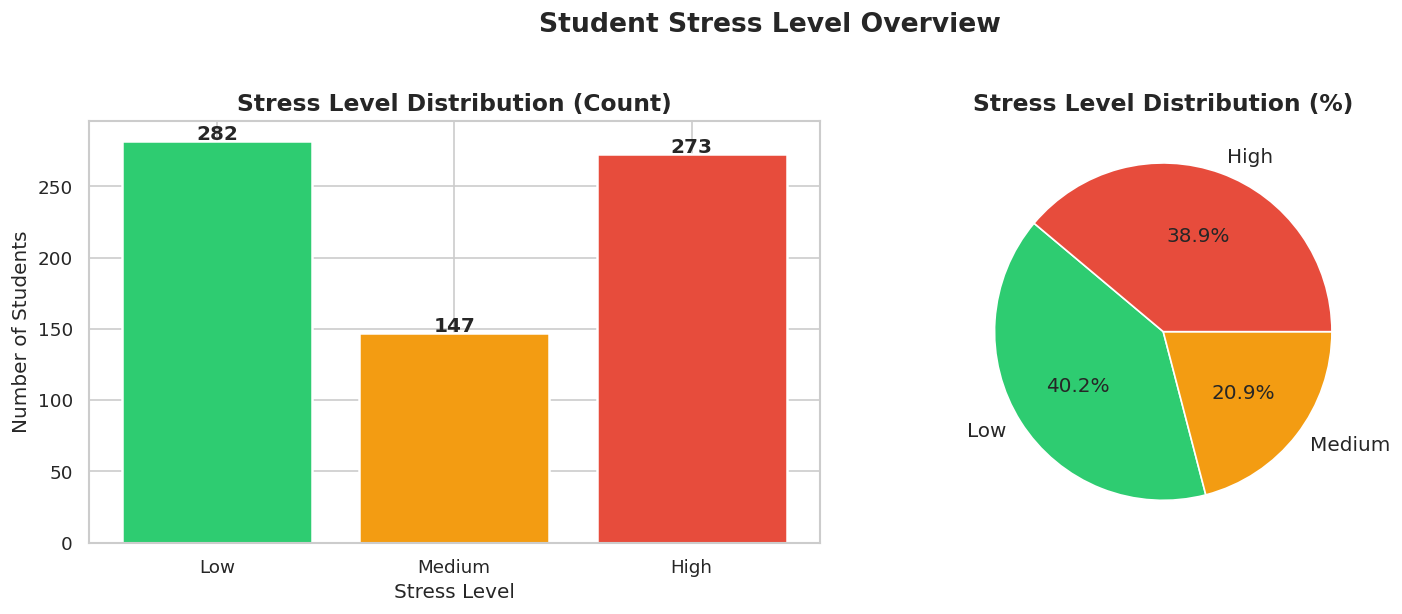

📌 Insight: This shows how stress is distributed among students surveyed.


In [24]:
# ── 5.1 Target Variable Distribution ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Count plot
order = ['Low', 'Medium', 'High']
colors = ['#2ecc71', '#f39c12', '#e74c3c']
counts = df['stress_category'].value_counts()
axes[0].bar(order, [counts.get(k, 0) for k in order], color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Stress Level Distribution (Count)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Stress Level')
axes[0].set_ylabel('Number of Students')
for i, (k, c) in enumerate(zip(order, colors)):
    axes[0].text(i, counts.get(k, 0) + 1, str(counts.get(k, 0)), ha='center', fontweight='bold')

# Pie chart
axes[1].pie([counts.get(k, 0) for k in order], labels=order, colors=colors,
            autopct='%1.1f%%', startangle=140, textprops={'fontsize': 12})
axes[1].set_title('Stress Level Distribution (%)', fontsize=14, fontweight='bold')

plt.suptitle('Student Stress Level Overview', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print('📌 Insight: This shows how stress is distributed among students surveyed.')

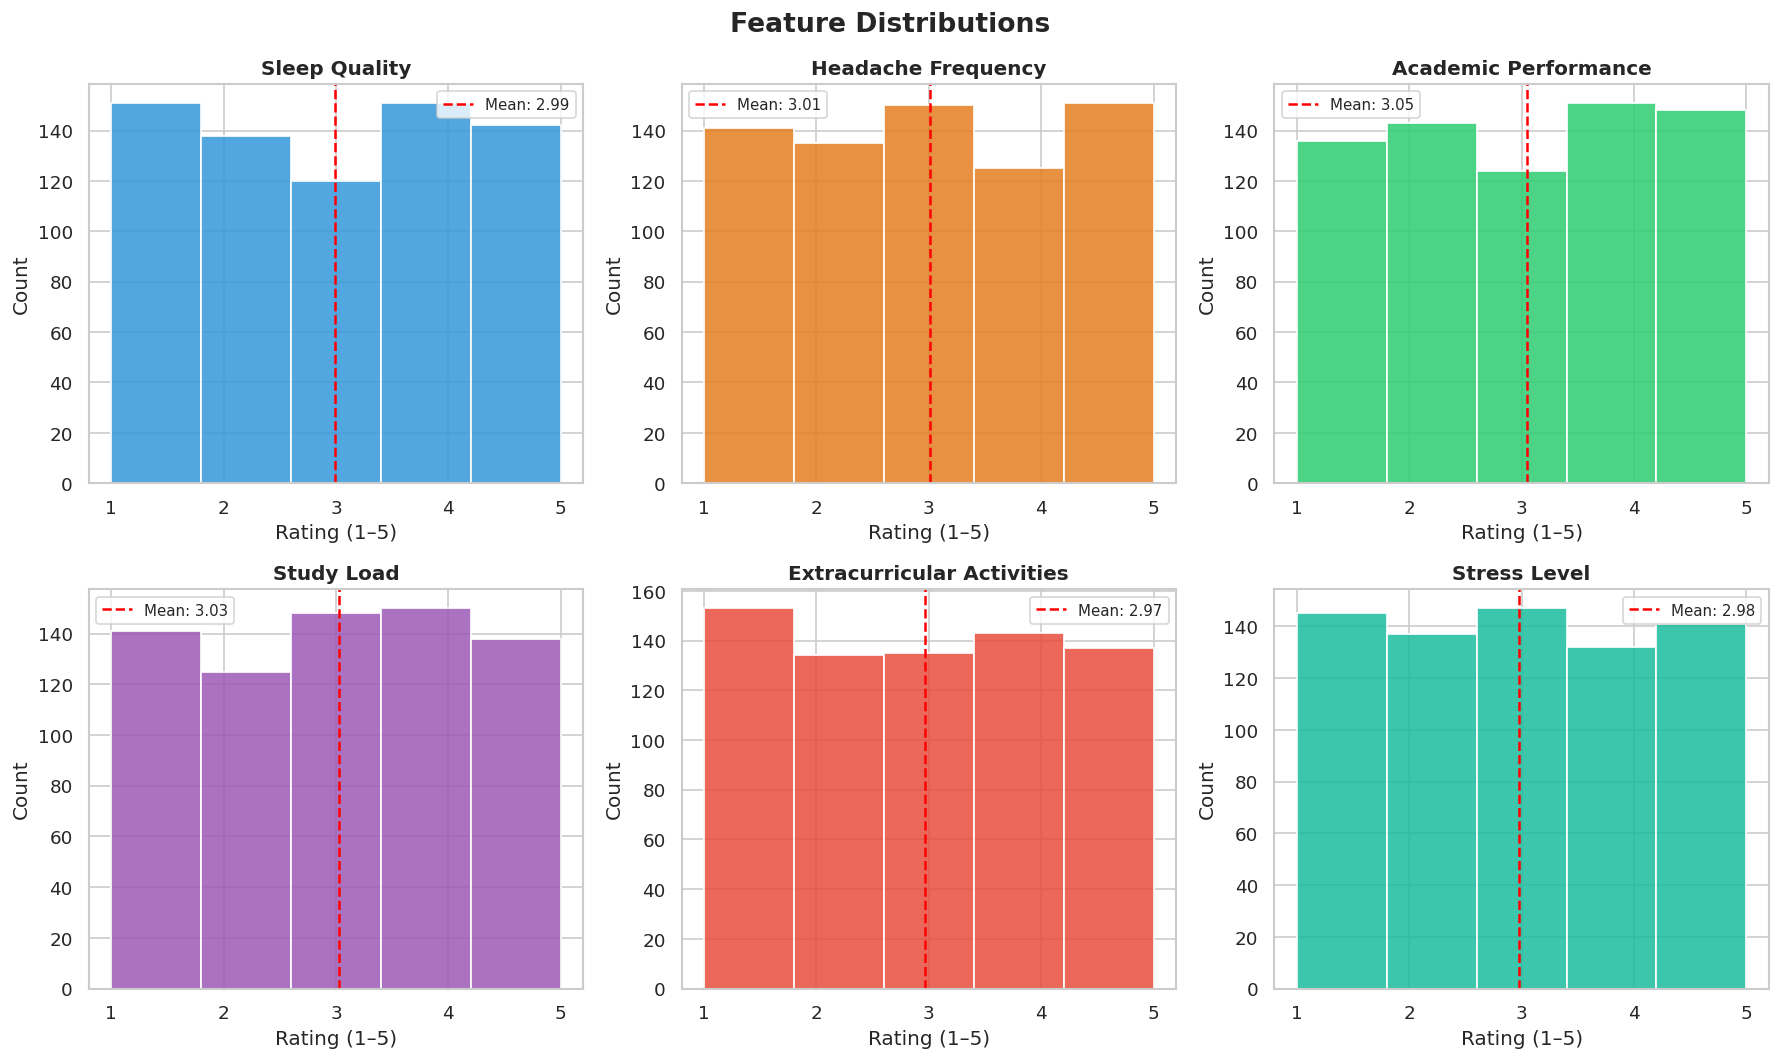

📌 Insight: Red dashed line shows the mean rating for each feature.


In [25]:
# ── 5.2 Distribution of Each Feature ─────────────────────────────────────────
features = ['sleep_quality', 'headache_frequency', 'academic_performance',
            'study_load', 'extracurricular_activities', 'stress_level']

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

palette = ['#3498db', '#e67e22', '#2ecc71', '#9b59b6', '#e74c3c', '#1abc9c']

for i, (col, color) in enumerate(zip(features, palette)):
    axes[i].hist(df[col], bins=5, color=color, edgecolor='white', linewidth=1.2, alpha=0.85)
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Rating (1–5)')
    axes[i].set_ylabel('Count')
    mean_val = df[col].mean()
    axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:.2f}')
    axes[i].legend(fontsize=9)

plt.suptitle('Feature Distributions', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()
print('📌 Insight: Red dashed line shows the mean rating for each feature.')

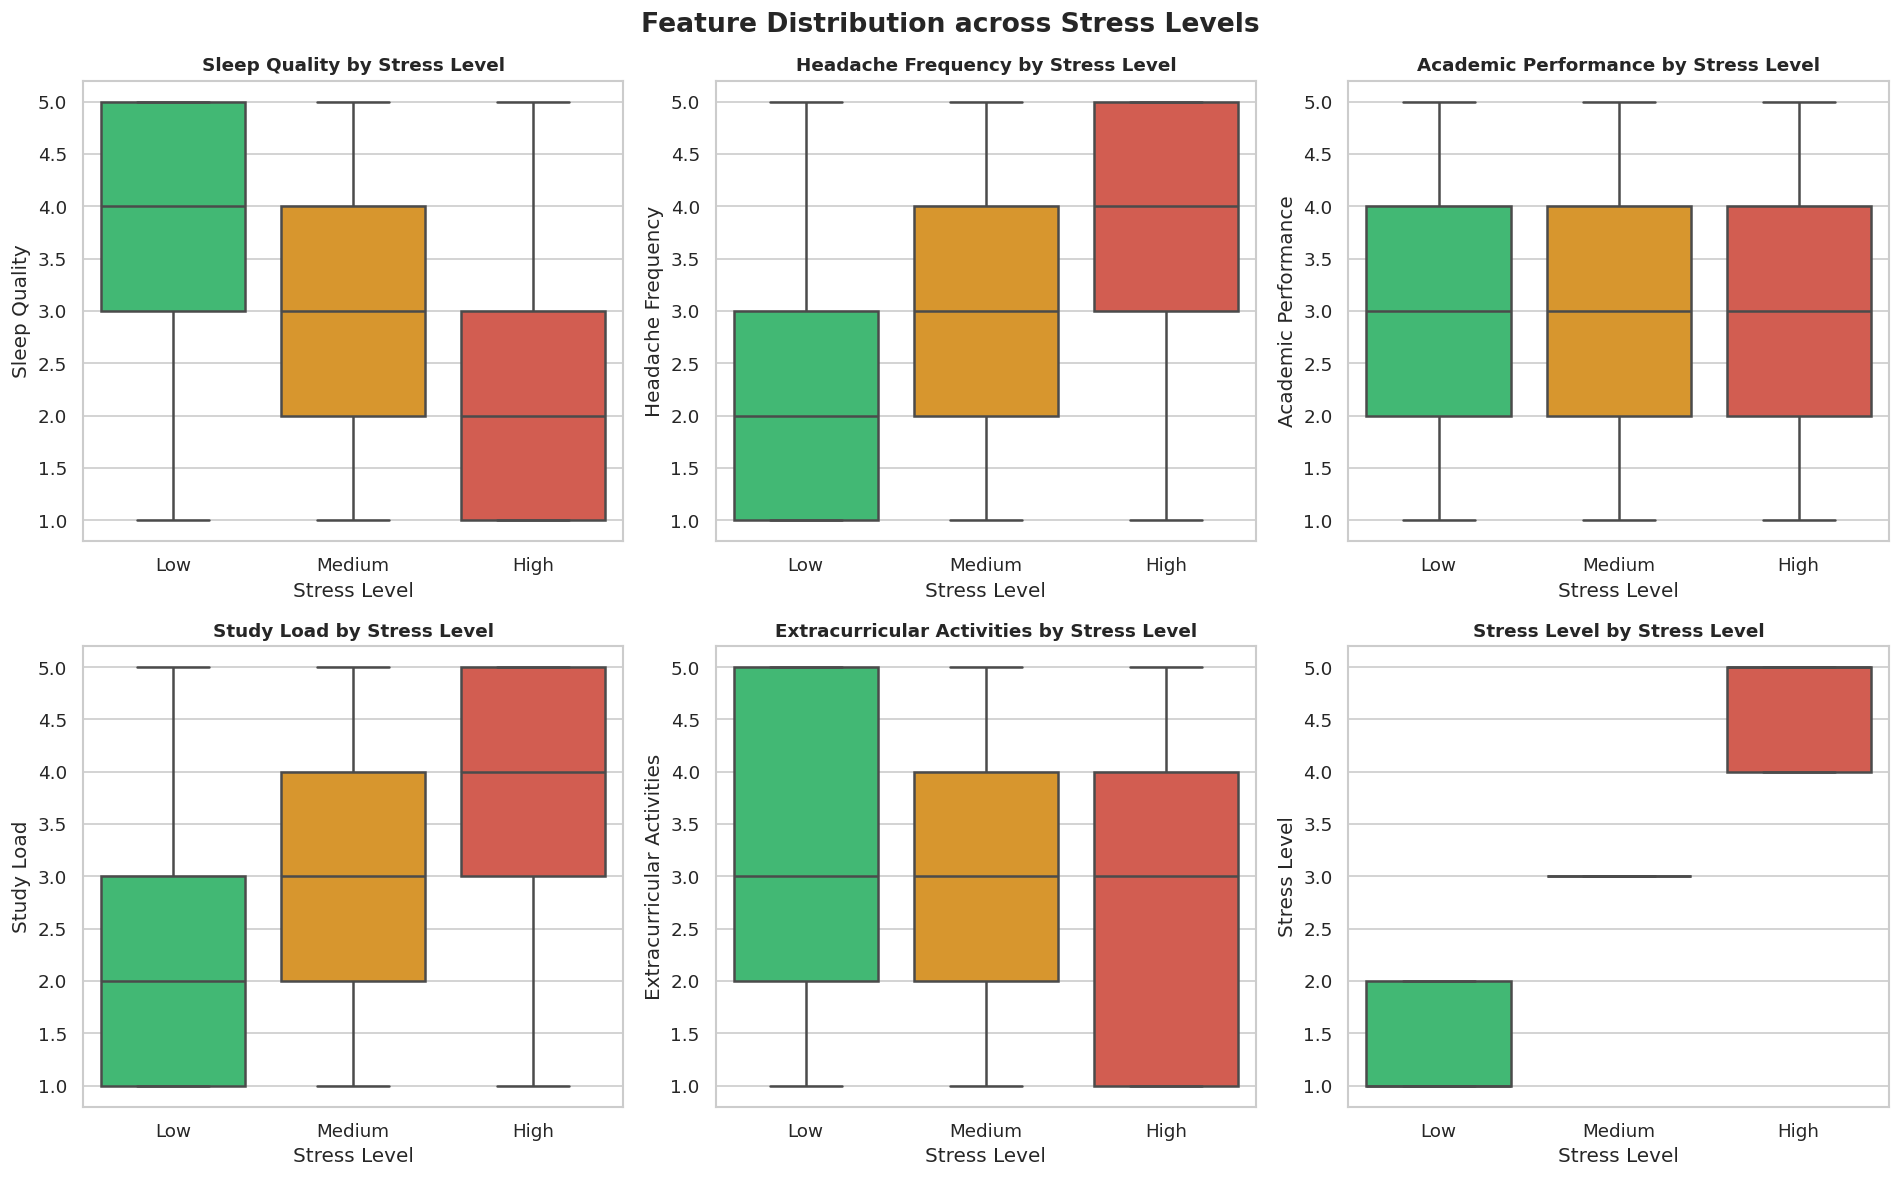

📌 Insight: Box plots reveal how each feature varies across Low/Medium/High stress groups.


In [26]:
# ── 5.3 Feature vs Stress Level (Box Plots) ───────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

input_features = ['sleep_quality', 'headache_frequency', 'academic_performance',
                  'study_load', 'extracurricular_activities', 'stress_level']

palette_box = {'Low': '#2ecc71', 'Medium': '#f39c12', 'High': '#e74c3c'}

for i, col in enumerate(input_features):
    sns.boxplot(data=df, x='stress_category', y=col, order=['Low','Medium','High'],
                palette=palette_box, ax=axes[i], linewidth=1.5)
    axes[i].set_title(f'{col.replace("_"," ").title()} by Stress Level',
                      fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Stress Level')
    axes[i].set_ylabel(col.replace('_',' ').title())

plt.suptitle('Feature Distribution across Stress Levels', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()
print('📌 Insight: Box plots reveal how each feature varies across Low/Medium/High stress groups.')

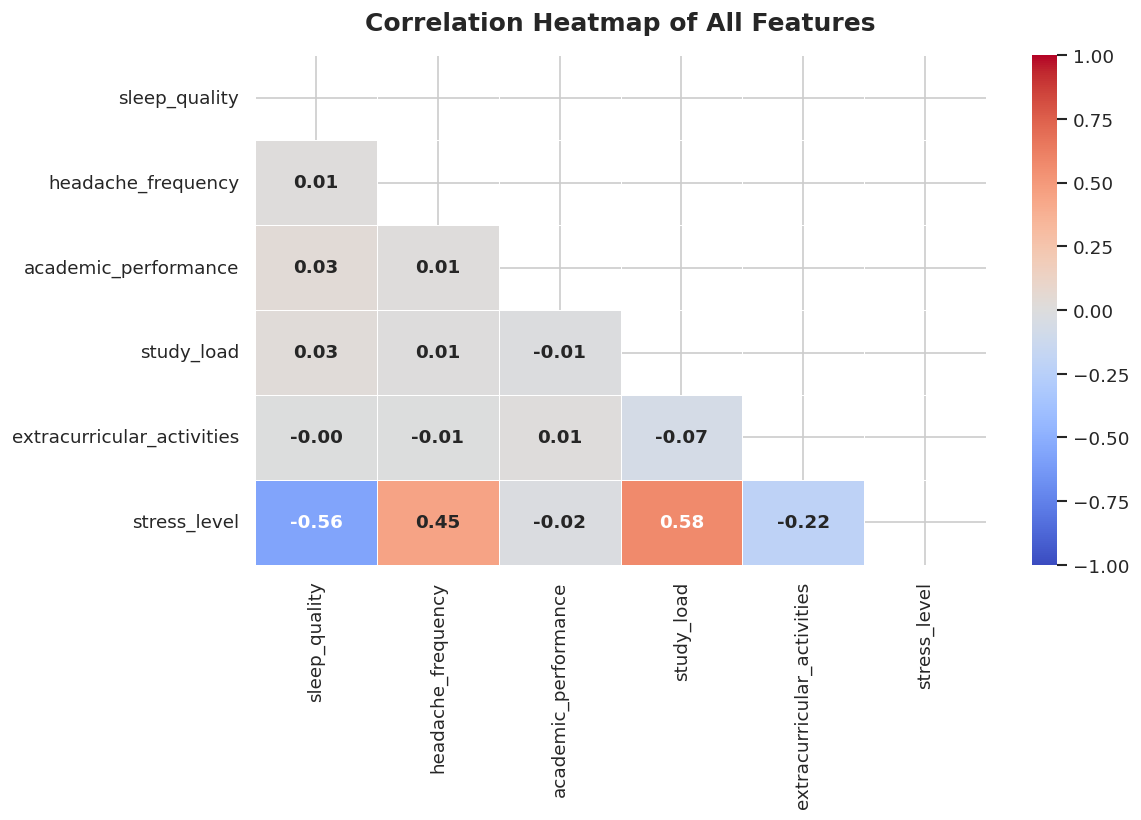

📌 Insight:
   • Values close to +1 → strong positive correlation
   • Values close to -1 → strong negative correlation
   • Values close to 0  → little/no linear relationship


In [27]:
# ── 5.4 Correlation Heatmap ───────────────────────────────────────────────────
plt.figure(figsize=(10, 7))
corr = df[features].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
    linewidths=0.5, vmin=-1, vmax=1,
    annot_kws={'size': 11, 'weight': 'bold'}
)

plt.title('Correlation Heatmap of All Features', fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()
print('📌 Insight:')
print('   • Values close to +1 → strong positive correlation')
print('   • Values close to -1 → strong negative correlation')
print('   • Values close to 0  → little/no linear relationship')

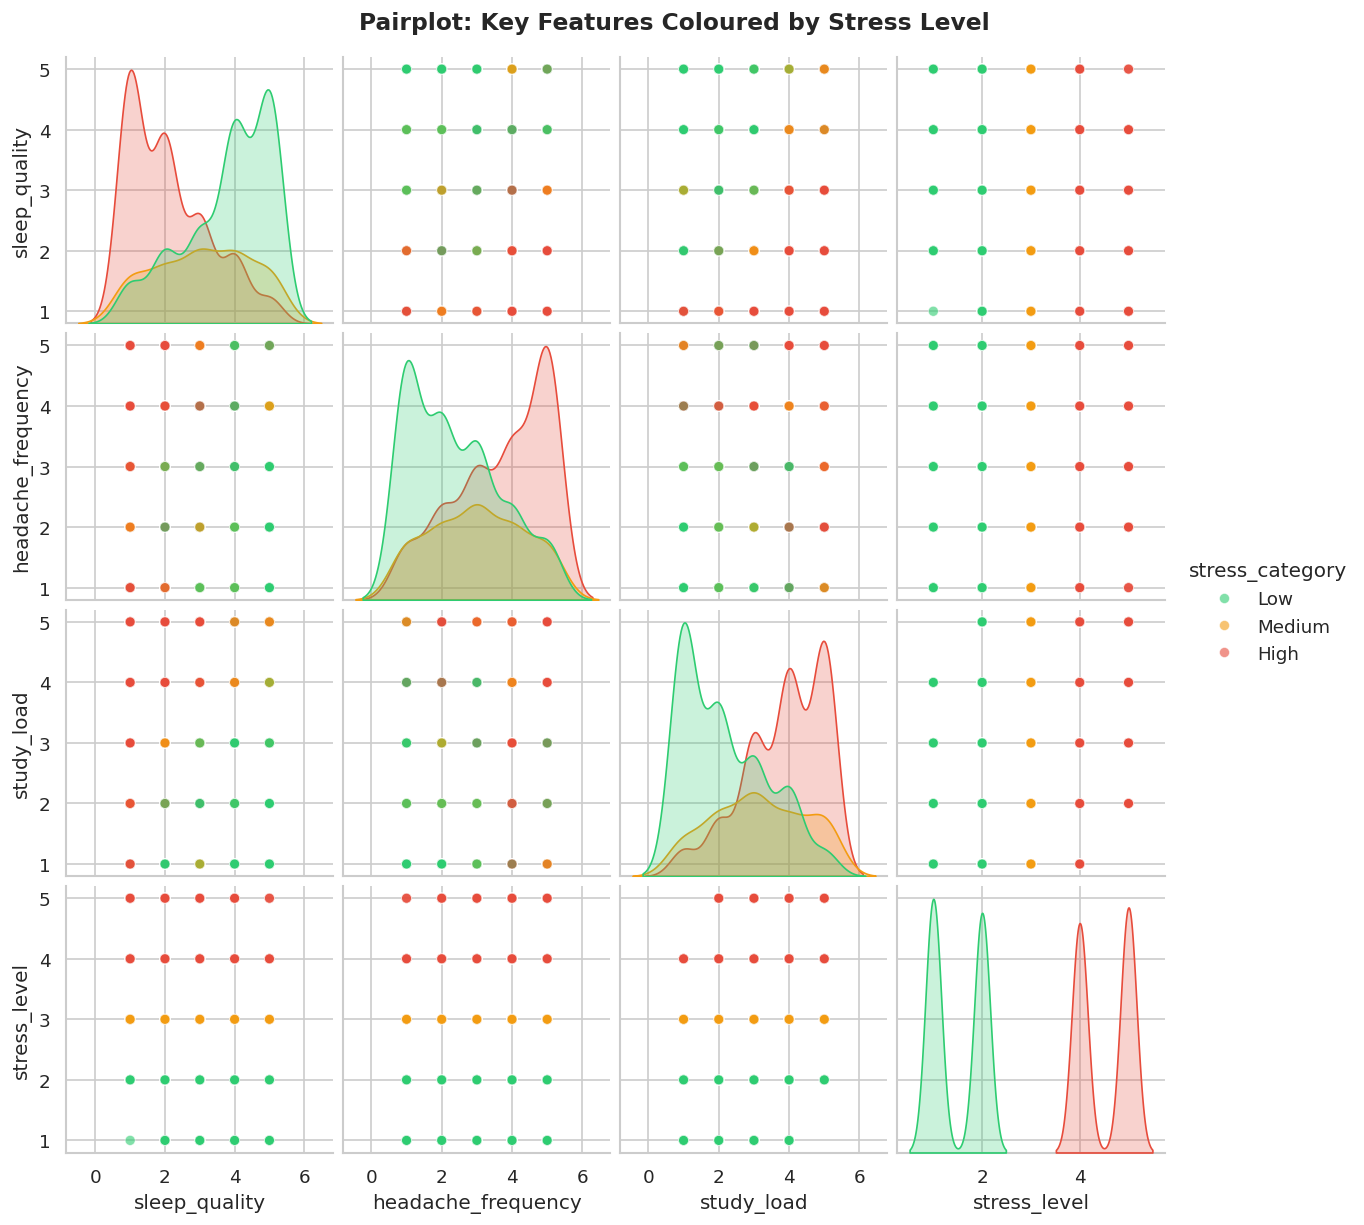

📌 Insight: Each scatter shows the relationship between two features, coloured by stress level.


In [28]:
# ── 5.5 Pairplot ──────────────────────────────────────────────────────────────
pair_df = df[['sleep_quality','headache_frequency','study_load','stress_level','stress_category']].copy()
pp = sns.pairplot(pair_df, hue='stress_category',
                  hue_order=['Low','Medium','High'],
                  palette={'Low':'#2ecc71','Medium':'#f39c12','High':'#e74c3c'},
                  diag_kind='kde', plot_kws={'alpha':0.6})
pp.fig.suptitle('Pairplot: Key Features Coloured by Stress Level',
                y=1.02, fontsize=14, fontweight='bold')
plt.show()
print('📌 Insight: Each scatter shows the relationship between two features, coloured by stress level.')

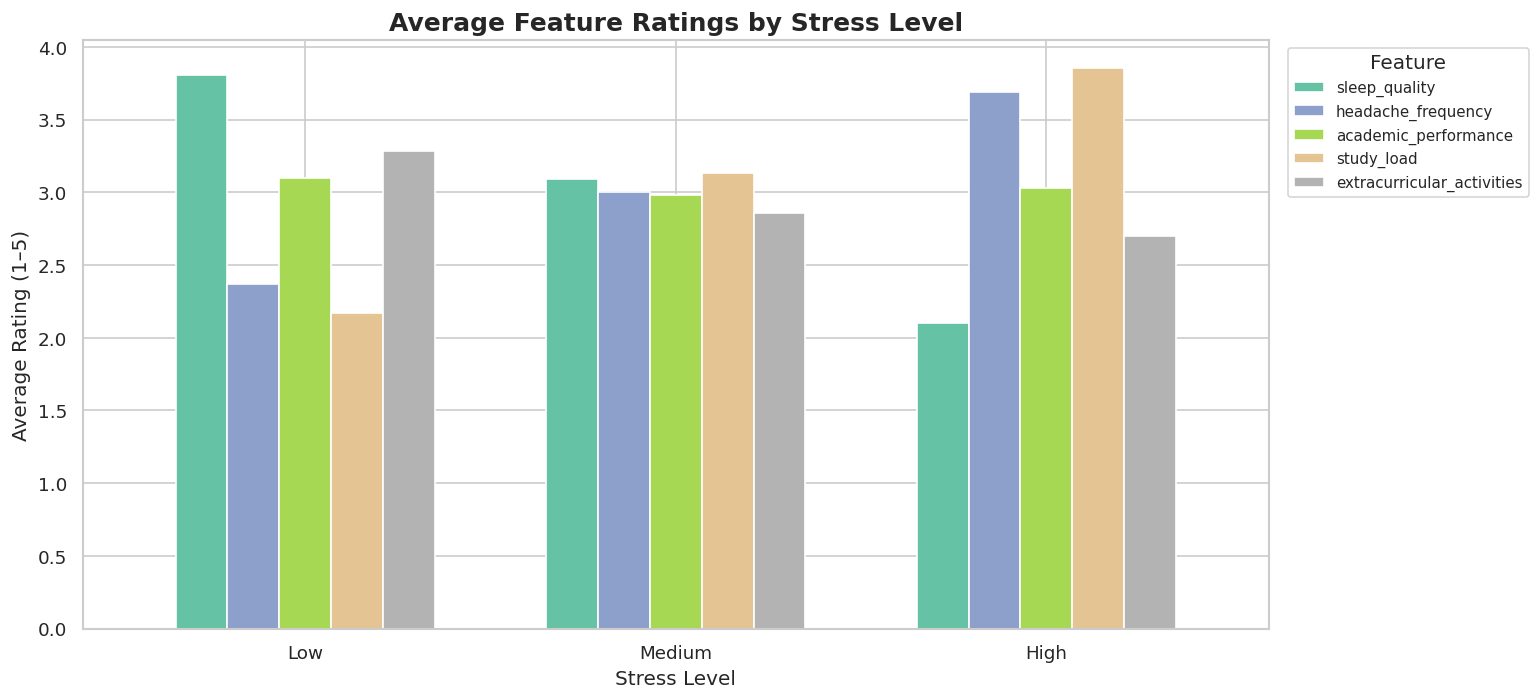

📌 Insight: Compare how each feature changes across Low, Medium, and High stress groups.


In [29]:
# ── 5.6 Average Feature Values per Stress Group ───────────────────────────────
avg = df.groupby('stress_category')[features[:-1]].mean().reindex(['Low','Medium','High'])

avg.plot(kind='bar', figsize=(13, 6), width=0.7, edgecolor='white', colormap='Set2')
plt.title('Average Feature Ratings by Stress Level', fontsize=15, fontweight='bold')
plt.xlabel('Stress Level')
plt.ylabel('Average Rating (1–5)')
plt.xticks(rotation=0)
plt.legend(title='Feature', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()
print('📌 Insight: Compare how each feature changes across Low, Medium, and High stress groups.')

---
## ⚙️ Step 6: Feature Engineering & Preprocessing

In [30]:
# ── Define Features and Target ────────────────────────────────────────────────
X = df[['sleep_quality', 'headache_frequency', 'academic_performance',
        'study_load', 'extracurricular_activities']]

y_raw = df['stress_category']

# ── Label Encode Target ───────────────────────────────────────────────────────
le = LabelEncoder()
le.fit(['Low', 'Medium', 'High'])
y = le.transform(y_raw)

print('Label Encoding:')
for cls, code in zip(le.classes_, le.transform(le.classes_)):
    print(f'  {cls} → {code}')

print(f'\nFeatures shape : {X.shape}')
print(f'Target shape   : {y.shape}')

Label Encoding:
  High → 0
  Low → 1
  Medium → 2

Features shape : (702, 5)
Target shape   : (702,)


In [31]:
# ── Feature Scaling ───────────────────────────────────────────────────────────
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print('✅ Features scaled using StandardScaler (mean=0, std=1)')
print()
print('Before scaling (head):')
print(X.head(3).to_string())
print()
print('After scaling (head):')
print(X_scaled.head(3).round(3).to_string())

✅ Features scaled using StandardScaler (mean=0, std=1)

Before scaling (head):
   sleep_quality  headache_frequency  academic_performance  study_load  extracurricular_activities
0              4                   3                     5           4                           1
1              5                   3                     2           4                           3
2              3                   4                     2           2                           3

After scaling (head):
   sleep_quality  headache_frequency  academic_performance  study_load  extracurricular_activities
0          0.698              -0.010                 1.370       0.691                      -1.375
1          1.391              -0.010                -0.733       0.691                       0.023
2          0.005               0.691                -0.733      -0.730                       0.023


In [32]:
# ── Train-Test Split (80% train / 20% test) ───────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print('Train-Test Split (Stratified):')
print(f'  Training samples : {X_train.shape[0]} ({X_train.shape[0]/len(y)*100:.0f}%)')
print(f'  Testing samples  : {X_test.shape[0]} ({X_test.shape[0]/len(y)*100:.0f}%)')
print()
print('Class distribution in training set:')
for cls, code in zip(le.classes_, le.transform(le.classes_)):
    n = (y_train == code).sum()
    print(f'  {cls:8s} ({code}) → {n} samples')

Train-Test Split (Stratified):
  Training samples : 561 (80%)
  Testing samples  : 141 (20%)

Class distribution in training set:
  High     (0) → 218 samples
  Low      (1) → 225 samples
  Medium   (2) → 118 samples


---
## 🤖 Step 7: Model Building & Comparison
We train and evaluate **6 different classifiers** to find the best model.

In [33]:
# ── Define all models ─────────────────────────────────────────────────────────
models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree'       : DecisionTreeClassifier(random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=42),
    'KNN'                 : KNeighborsClassifier(n_neighbors=5),
    'SVM'                 : SVC(kernel='rbf', random_state=42),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results = {}

print(f'{"Model":<25} {"Test Accuracy":>14} {"CV Mean (5-fold)":>18} {"CV Std":>10}')
print('-'*70)

for name, model in models.items():
    # Train
    model.fit(X_train, y_train)
    # Test accuracy
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    # Cross-validation
    cv = cross_val_score(model, X_scaled, y, cv=5, scoring='accuracy')
    results[name] = {
        'model': model, 'y_pred': y_pred,
        'test_acc': acc, 'cv_mean': cv.mean(), 'cv_std': cv.std()
    }
    print(f'{name:<25} {acc*100:>13.2f}%  {cv.mean()*100:>16.2f}%  ±{cv.std()*100:>7.2f}%')

best_name = max(results, key=lambda k: results[k]['cv_mean'])
print()
print(f'🏆 Best Model (by CV): {best_name} ({results[best_name]["cv_mean"]*100:.2f}%)')

Model                      Test Accuracy   CV Mean (5-fold)     CV Std
----------------------------------------------------------------------
Logistic Regression               95.74%             96.73%  ±   1.65%
Decision Tree                     85.82%             85.90%  ±   1.21%
Random Forest                     87.23%             88.32%  ±   1.53%
KNN                               80.85%             78.77%  ±   3.15%
SVM                               93.62%             92.45%  ±   1.85%
Gradient Boosting                 90.78%             90.88%  ±   2.83%

🏆 Best Model (by CV): Logistic Regression (96.73%)


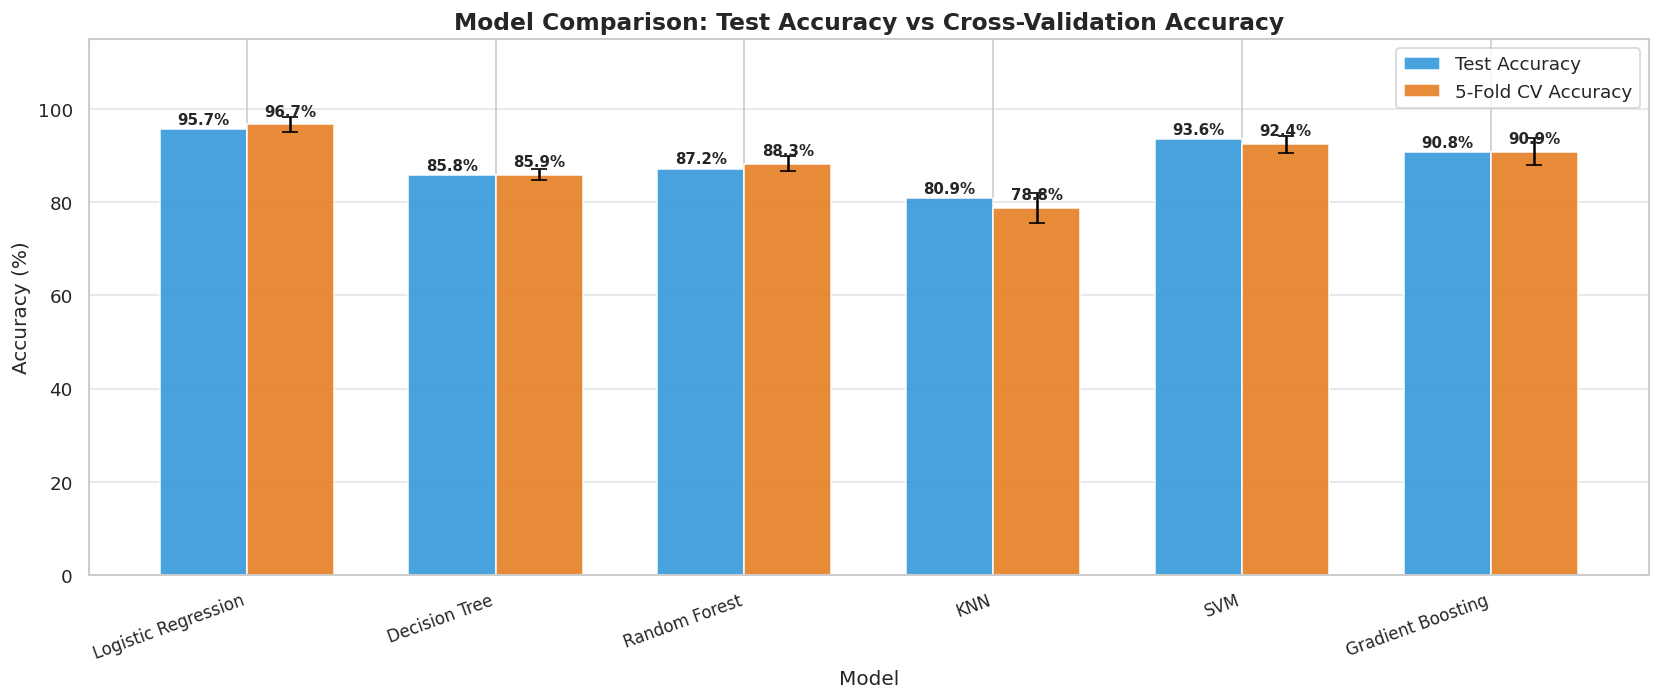

In [34]:
# ── Model Comparison Bar Chart ────────────────────────────────────────────────
names = list(results.keys())
test_accs = [results[n]['test_acc'] * 100 for n in names]
cv_means  = [results[n]['cv_mean'] * 100 for n in names]
cv_stds   = [results[n]['cv_std'] * 100 for n in names]

x = np.arange(len(names))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
bars1 = ax.bar(x - width/2, test_accs, width, label='Test Accuracy',
               color='#3498db', edgecolor='white', alpha=0.9)
bars2 = ax.bar(x + width/2, cv_means, width, yerr=cv_stds, label='5-Fold CV Accuracy',
               color='#e67e22', edgecolor='white', alpha=0.9, capsize=5)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.2,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Model Comparison: Test Accuracy vs Cross-Validation Accuracy',
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=20, ha='right', fontsize=10)
ax.set_ylim(0, 115)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.5)
plt.tight_layout()
plt.show()

---
## 🔧 Step 8: Hyperparameter Tuning (Best Model)

In [35]:
# ── Grid Search on Random Forest ──────────────────────────────────────────────
print('🔧 Hyperparameter Tuning: Random Forest (GridSearchCV)')
print('   This finds the best combination of parameters automatically.')
print()

param_grid = {
    'n_estimators'    : [50, 100, 200],
    'max_depth'       : [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'criterion'       : ['gini', 'entropy']
}

rf_base = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(
    rf_base, param_grid, cv=5,
    scoring='accuracy', n_jobs=-1, verbose=0
)
grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_
best_rf = grid_search.best_estimator_

print('Best Parameters Found:')
for k, v in best_params.items():
    print(f'  {k:20s} : {v}')

tuned_acc = accuracy_score(y_test, best_rf.predict(X_test))
print()
print(f'✅ Tuned Random Forest Test Accuracy: {tuned_acc*100:.2f}%')

🔧 Hyperparameter Tuning: Random Forest (GridSearchCV)
   This finds the best combination of parameters automatically.

Best Parameters Found:
  criterion            : entropy
  max_depth            : None
  min_samples_split    : 2
  n_estimators         : 200

✅ Tuned Random Forest Test Accuracy: 86.52%


---
## 📈 Step 9: Final Model Evaluation

In [36]:
# ── Detailed Classification Report ───────────────────────────────────────────
y_final_pred = best_rf.predict(X_test)
target_names = le.classes_

print('='*55)
print('  FINAL MODEL: Tuned Random Forest')
print('='*55)
print()
print(classification_report(y_test, y_final_pred,
                             target_names=target_names))

  FINAL MODEL: Tuned Random Forest

              precision    recall  f1-score   support

        High       0.91      0.95      0.93        55
         Low       0.91      0.89      0.90        57
      Medium       0.68      0.66      0.67        29

    accuracy                           0.87       141
   macro avg       0.83      0.83      0.83       141
weighted avg       0.86      0.87      0.86       141



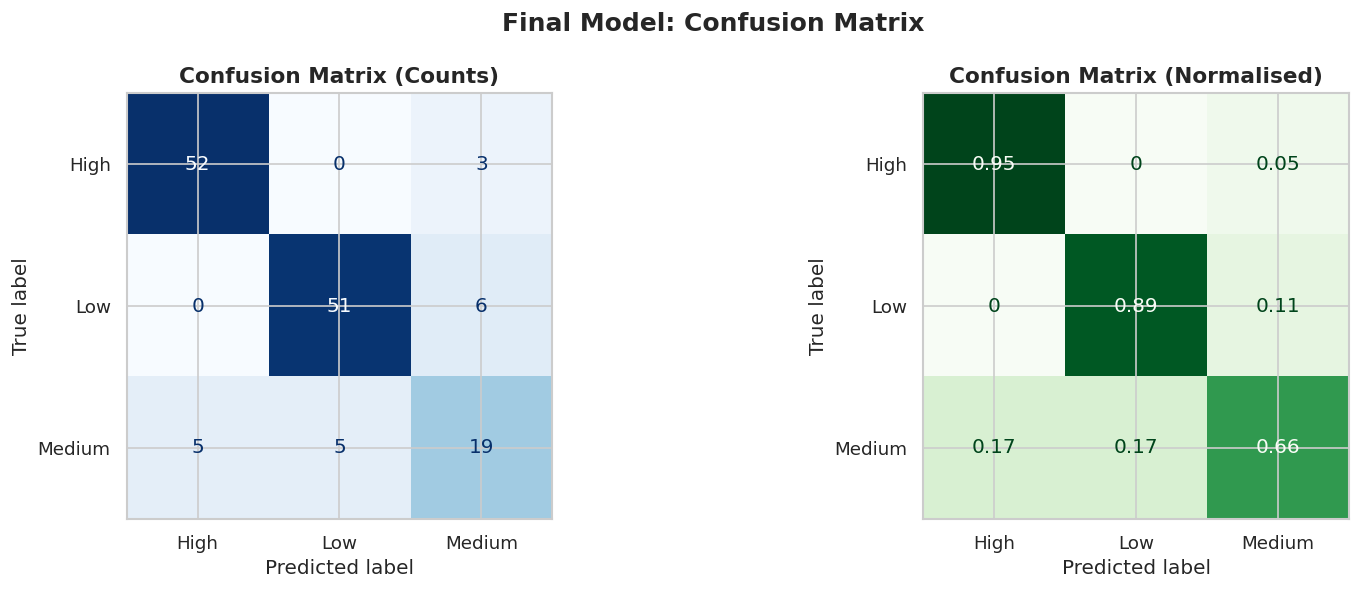

📌 Diagonal cells = correct predictions. Off-diagonal = misclassifications.


In [37]:
# ── Confusion Matrix ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
cm = confusion_matrix(y_test, y_final_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix (Counts)', fontsize=13, fontweight='bold')

# Normalised
cm_norm = confusion_matrix(y_test, y_final_pred, normalize='true')
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_norm.round(2), display_labels=target_names)
disp2.plot(ax=axes[1], colorbar=False, cmap='Greens')
axes[1].set_title('Confusion Matrix (Normalised)', fontsize=13, fontweight='bold')

plt.suptitle('Final Model: Confusion Matrix', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
print('📌 Diagonal cells = correct predictions. Off-diagonal = misclassifications.')

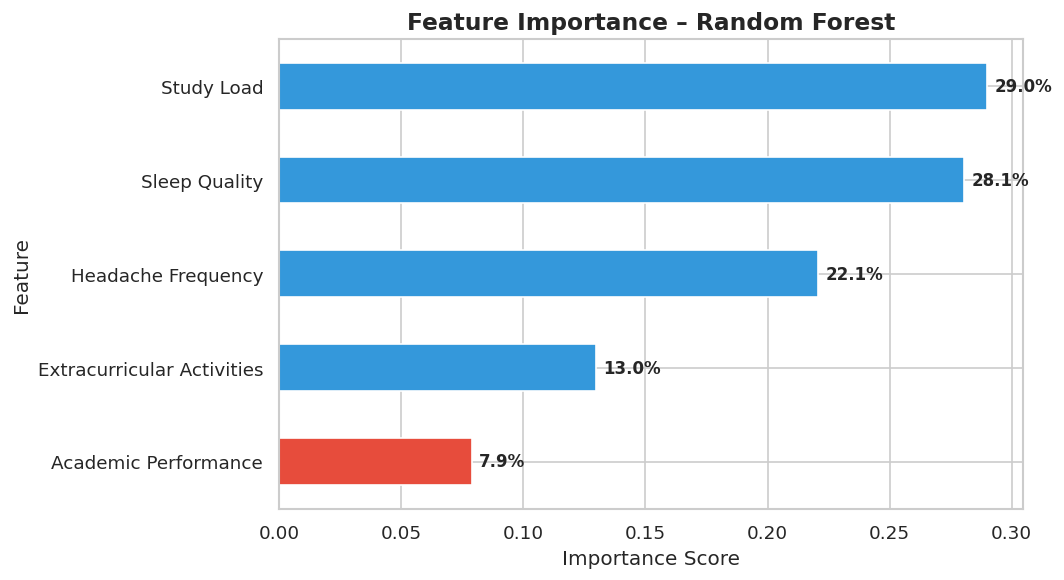

📌 Most important feature: Study Load (29.0%)


In [38]:
# ── Feature Importance ────────────────────────────────────────────────────────
importances = best_rf.feature_importances_
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
colors_imp = ['#e74c3c' if v == feat_imp.max() else '#3498db' for v in feat_imp]
bars = feat_imp.plot(kind='barh', ax=ax, color=colors_imp[::-1], edgecolor='white')

for i, (val, name) in enumerate(zip(feat_imp, feat_imp.index)):
    ax.text(val + 0.003, i, f'{val*100:.1f}%', va='center', fontsize=10, fontweight='bold')

ax.set_title('Feature Importance – Random Forest', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.set_ylabel('Feature')
ax.set_yticklabels([f.replace('_',' ').title() for f in feat_imp.index], fontsize=11)
plt.tight_layout()
plt.show()

top = feat_imp.idxmax()
print(f'📌 Most important feature: {top.replace("_"," ").title()} ({feat_imp.max()*100:.1f}%)')

---
## ⚖️ Step 10: Ethics, Bias & Limitations Analysis

Responsible Data Science requires us to honestly evaluate the ethical dimensions and limitations of our work.

### 1. Potential Biases
| Bias Type | Description |
|-----------|-------------|
| **Sampling Bias** | The dataset may not represent all students globally. Responses depend on self-reporting which can be subjective. |
| **Cultural Bias** | Stress perception differs across cultures and regions. A model trained on one group may not generalise. |
| **Label Bias** | The target (stress level) is based on self-rating (1–5), not clinical diagnosis. Two students may rate the same experience differently. |
| **Class Imbalance** | If one stress level has far fewer samples, the model may be biased towards majority classes. |

### 2. Ethical Considerations
- **Privacy:** Mental health data is highly sensitive. Student data should never be collected or stored without **explicit informed consent**.
- **Fairness:** The model should not discriminate based on demographic factors (gender, age, background).
- **Misuse Risk:** A model predicting stress levels could be misused by institutions to penalise students rather than support them.
- **Over-reliance:** This tool should assist mental health professionals — not replace clinical diagnosis.

### 3. Limitations
- The dataset uses a Likert scale (1–5) which is ordinal — treating it as continuous may lose meaning.
- Physical, genetic, and environmental factors are not captured in this dataset.
- The model is trained on historical survey data; it cannot capture dynamic or real-time stress changes.
- Model accuracy is never 100% — misclassification of a genuinely distressed student could have real consequences.

---
## ✅ Step 11: Conclusion & Insights

In [39]:
# ── Final Summary ─────────────────────────────────────────────────────────────
print('='*60)
print('  PROJECT SUMMARY – STUDENT STRESS ANALYSER')
print('='*60)
print()
print('📊 DATASET')
print(f'   Rows       : {df.shape[0]}')
print(f'   Features   : {X.shape[1]}')
print(f'   Target     : Stress Level (Low / Medium / High)')
print()
print('🤖 MODEL RESULTS')
print(f'   Best Model : Tuned Random Forest')
print(f'   Accuracy   : {tuned_acc*100:.2f}%')
print()
print('🔑 KEY FINDINGS')
for i, (feat, imp) in enumerate(feat_imp.sort_values(ascending=False).items(), 1):
    print(f'   {i}. {feat.replace("_"," ").title():30s} Importance: {imp*100:.1f}%')
print()
print('💡 RECOMMENDATIONS')
print('   • Students with poor sleep quality showed higher stress levels.')
print('   • Reducing excessive study load can help manage stress.')
print('   • Regular extracurricular activities act as stress relievers.')
print('   • Early identification using this model can help counsellors')
print('     prioritise at-risk students proactively.')
print()
print('='*60)
print('  Thank you! – IILM University Data Science PBL Project')
print('='*60)

  PROJECT SUMMARY – STUDENT STRESS ANALYSER

📊 DATASET
   Rows       : 702
   Features   : 5
   Target     : Stress Level (Low / Medium / High)

🤖 MODEL RESULTS
   Best Model : Tuned Random Forest
   Accuracy   : 86.52%

🔑 KEY FINDINGS
   1. Study Load                     Importance: 29.0%
   2. Sleep Quality                  Importance: 28.1%
   3. Headache Frequency             Importance: 22.1%
   4. Extracurricular Activities     Importance: 13.0%
   5. Academic Performance           Importance: 7.9%

💡 RECOMMENDATIONS
   • Students with poor sleep quality showed higher stress levels.
   • Reducing excessive study load can help manage stress.
   • Regular extracurricular activities act as stress relievers.
   • Early identification using this model can help counsellors
     prioritise at-risk students proactively.

  Thank you! – IILM University Data Science PBL Project
